In [1]:
from google.colab import files

uploaded = files.upload()


Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [2]:
import os

os.listdir()


['.config',
 'RUL_FD001.txt',
 'test_FD001.txt',
 'train_FD001.txt',
 'sample_data']

In [3]:
import pandas as pd

col_names = ['engine_id', 'cycle',
             'setting_1', 'setting_2', 'setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv("train_FD001.txt", sep=" ", header=None)
train_df = train_df.dropna(axis=1, how='all')
train_df.columns = col_names

train_df.head()


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print(train_df.shape)
print(train_df['engine_id'].nunique(), "engines")
print("Max cycle per engine:", train_df.groupby('engine_id')['cycle'].max().max())

train_df[train_df['engine_id'] == 1].head(10)


(20631, 26)
100 engines
Max cycle per engine: 362


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [5]:

max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

train_df = train_df.merge(max_cycle, on='engine_id', how='left')

train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

train_df = train_df.drop(columns=['max_cycle'])

train_df.head(10)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,186
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,185
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,184
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,183
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,182


In [6]:
train_df[train_df['engine_id'] == 1][['cycle', 'RUL']].head(15)


,cycle,RUL
0,1,191
1,2,190
2,3,189
3,4,188
4,5,187
5,6,186
6,7,185
7,8,184
8,9,183
9,10,182


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = train_df.drop(columns=['engine_id', 'cycle', 'RUL'])

y = train_df['RUL']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Linear Regression RMSE:", rmse)
print("R² Score:", r2)


Linear Regression RMSE: 44.34186807015132
R² Score: 0.569645560744755


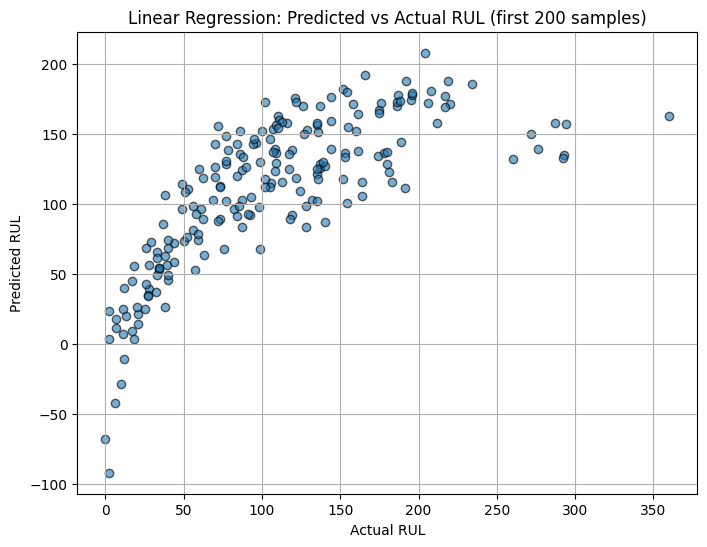

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_val[:200], y_pred[:200], alpha=0.6, edgecolors='k')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression: Predicted vs Actual RUL (first 200 samples)")
plt.grid(True)
plt.show()


In [10]:
healthy_df = train_df[train_df['RUL'] > 120]

X_ae = healthy_df.drop(columns=['engine_id', 'cycle', 'RUL'])

scaler_ae = StandardScaler()
X_ae_scaled = scaler_ae.fit_transform(X_ae)

X_ae_scaled.shape


(8531, 24)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_ae_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088 (4.25 KB)

 Trainable params: 1,088 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = autoencoder.fit(
    X_ae_scaled, X_ae_scaled,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6581 - val_loss: 0.4157
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4054 - val_loss: 0.3593
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3535 - val_loss: 0.3223
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3144 - val_loss: 0.2963
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2887 - val_loss: 0.2767
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2668 - val_loss: 0.2515
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2405 - val_loss: 0.2240
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2189 - val_loss: 0.2090
Epoch 9/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2052 - val_loss: 0.1957
Epoch 10/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1921 - val_loss: 0.1862
Epoch 11/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1844 - val_loss: 0.1812
Epoch 12/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [13]:
import numpy as np

reconstructions = autoencoder.predict(X_ae_scaled)
train_loss = np.mean(np.square(X_ae_scaled - reconstructions), axis=1)

threshold = np.mean(train_loss) + 3*np.std(train_loss)
print("Reconstruction error threshold:", threshold)


267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction error threshold: 0.3694599042275115


In [14]:
X_full = train_df.drop(columns=['engine_id', 'cycle', 'RUL'])
X_full_scaled = scaler_ae.transform(X_full)

reconstructions_full = autoencoder.predict(X_full_scaled)
loss_full = np.mean(np.square(X_full_scaled - reconstructions_full), axis=1)

train_df['recon_error'] = loss_full
train_df['anomaly'] = train_df['recon_error'] > threshold

train_df[['engine_id','cycle','RUL','recon_error','anomaly']].head(20)


645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,engine_id,cycle,RUL,recon_error,anomaly
0,1,1,191,0.147405,False
1,1,2,190,0.107471,False
2,1,3,189,0.108003,False
3,1,4,188,0.222186,False
4,1,5,187,0.074138,False
5,1,6,186,0.093724,False
6,1,7,185,0.063814,False
7,1,8,184,0.187382,False
8,1,9,183,0.184599,False
9,1,10,182,0.223000,False


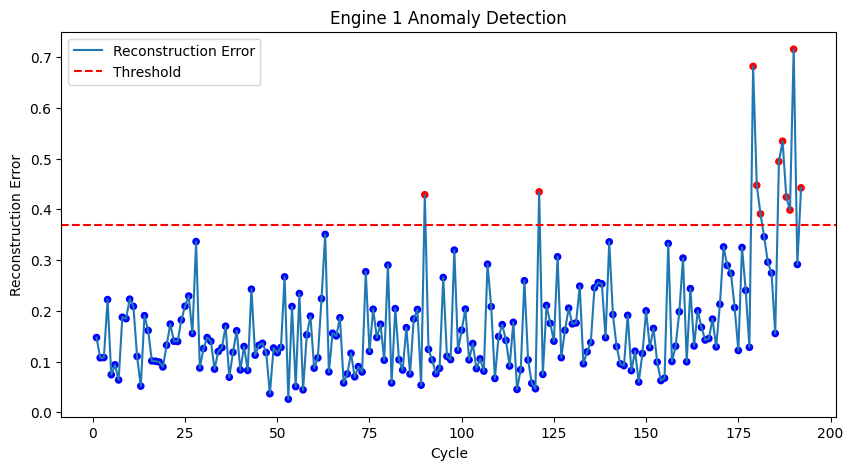

In [15]:
import matplotlib.pyplot as plt

engine_id = 1
subset = train_df[train_df['engine_id']==engine_id]

plt.figure(figsize=(10,5))
plt.plot(subset['cycle'], subset['recon_error'], label="Reconstruction Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.scatter(subset['cycle'], subset['recon_error'],
            c=subset['anomaly'].map({True:'red', False:'blue'}), s=20)
plt.xlabel("Cycle")
plt.ylabel("Reconstruction Error")
plt.title(f"Engine {engine_id} Anomaly Detection")
plt.legend()
plt.show()


In [16]:
test_df = pd.read_csv("test_FD001.txt", sep=" ", header=None)
test_df = test_df.dropna(axis=1, how='all')  # remove empty cols
test_df.columns = col_names  # same columns as training

rul_truth = pd.read_csv("RUL_FD001.txt", header=None)
rul_truth.columns = ['RUL']
rul_truth.head()


,RUL
0,112
1,98
2,69
3,82
4,91


In [17]:
max_cycle_test = test_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle_test.columns = ['engine_id', 'last_cycle']

max_cycle_test['truth_RUL'] = rul_truth['RUL']

test_df = test_df.merge(max_cycle_test, on='engine_id', how='left')

test_df['RUL'] = test_df['truth_RUL'] + (test_df['last_cycle'] - test_df['cycle'])

test_df = test_df.drop(columns=['last_cycle','truth_RUL'])

test_df.head(10)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138
5,1,6,0.0012,0.0003,100.0,518.67,642.11,1579.12,1395.13,14.62,...,2388.08,8127.46,8.4238,0.03,392,2388,100.0,38.91,23.3467,137
6,1,7,-0.0000,0.0002,100.0,518.67,642.11,1583.34,1404.84,14.62,...,2388.06,8134.97,8.3914,0.03,391,2388,100.0,38.85,23.3952,136
7,1,8,0.0006,-0.0000,100.0,518.67,642.54,1580.89,1400.89,14.62,...,2388.06,8125.93,8.4213,0.03,393,2388,100.0,39.05,23.3224,135
8,1,9,-0.0036,0.0000,100.0,518.67,641.88,1593.29,1412.28,14.62,...,2388.05,8134.15,8.4353,0.03,391,2388,100.0,39.10,23.4521,134
9,1,10,-0.0025,-0.0001,100.0,518.67,642.07,1585.25,1398.64,14.62,...,2388.06,8134.08,8.4093,0.03,391,2388,100.0,38.87,23.3820,133


In [18]:
X_test = test_df.drop(columns=['engine_id','cycle','RUL'])
X_test_scaled = scaler_ae.transform(X_test)

reconstructions_test = autoencoder.predict(X_test_scaled)
loss_test = np.mean(np.square(X_test_scaled - reconstructions_test), axis=1)

test_df['recon_error'] = loss_test
test_df['anomaly'] = test_df['recon_error'] > threshold

test_df[['engine_id','cycle','RUL','recon_error','anomaly']].head(20)


410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,engine_id,cycle,RUL,recon_error,anomaly
0,1,1,142,0.113445,False
1,1,2,141,0.234687,False
2,1,3,140,0.088593,False
3,1,4,139,0.144119,False
4,1,5,138,0.083288,False
5,1,6,137,0.124100,False
6,1,7,136,0.029730,False
7,1,8,135,0.089408,False
8,1,9,134,0.190095,False
9,1,10,133,0.042641,False


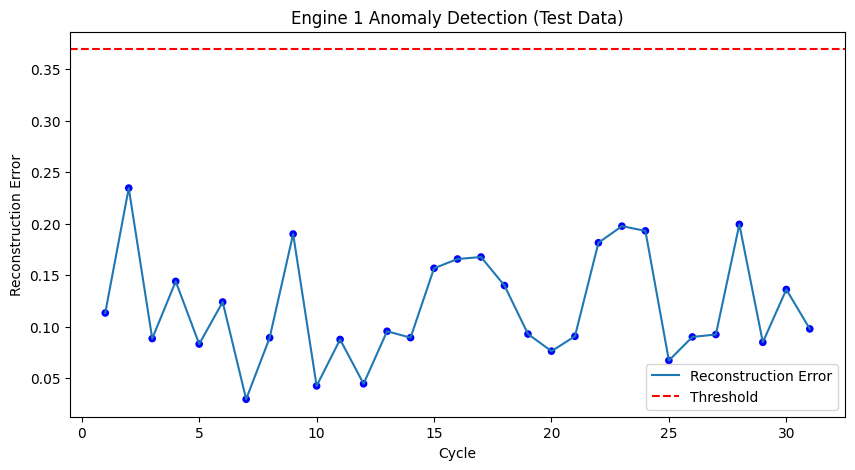

In [19]:
engine_id = 1
subset = test_df[test_df['engine_id']==engine_id]

plt.figure(figsize=(10,5))
plt.plot(subset['cycle'], subset['recon_error'], label="Reconstruction Error")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.scatter(subset['cycle'], subset['recon_error'],
            c=subset['anomaly'].map({True:'red', False:'blue'}), s=20)
plt.xlabel("Cycle")
plt.ylabel("Reconstruction Error")
plt.title(f"Engine {engine_id} Anomaly Detection (Test Data)")
plt.legend()
plt.show()


In [20]:
def assign_phase(row, total_cycles):
    if row['cycle'] <= 0.15 * total_cycles:
        return 'startup'
    elif row['cycle'] >= 0.85 * total_cycles:
        return 'shutdown'
    else:
        return 'steady'

train_df['phase'] = train_df.groupby('engine_id').apply(
    lambda group: group.apply(
        lambda row: assign_phase(row, group['cycle'].max()), axis=1
    )
).reset_index(drop=True)

train_df[['engine_id','cycle','phase','RUL']].head(20)


/tmp/ipython-input-625179124.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df['phase'] = train_df.groupby('engine_id').apply(


,engine_id,cycle,phase,RUL
0,1,1,startup,191
1,1,2,startup,190
2,1,3,startup,189
3,1,4,startup,188
4,1,5,startup,187
5,1,6,startup,186
6,1,7,startup,185
7,1,8,startup,184
8,1,9,startup,183
9,1,10,startup,182


In [21]:
phase_models = {}
phase_scalers = {}

for phase in ['startup','steady','shutdown']:
    print(f"\nTraining autoencoder for {phase} phase...")

    phase_data = train_df[train_df['phase'] == phase]
    X_phase = phase_data.drop(columns=['engine_id','cycle','RUL','phase'])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_phase)
    phase_scalers[phase] = scaler

    input_dim = X_scaled.shape[1]
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(input_dim, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_scaled, X_scaled, epochs=15, batch_size=64, verbose=0)

    phase_models[phase] = model

print("✅ Trained autoencoders for all phases")



Training autoencoder for startup phase...

Training autoencoder for steady phase...

Training autoencoder for shutdown phase...
✅ Trained autoencoders for all phases


In [23]:
results = []

for phase in ['startup','steady','shutdown']:
    phase_data = test_df[test_df['phase']==phase]
    X_phase = phase_data.drop(columns=['engine_id','cycle','RUL','phase'])

    X_scaled = phase_scalers[phase].transform(X_phase)

    recon = phase_models[phase].predict(X_scaled, verbose=0)
    losses = np.mean((X_scaled - recon)**2, axis=1)

    phase_data = phase_data.copy()
    phase_data['recon_error'] = losses
    phase_data['anomaly'] = losses > (losses.mean() + 3*losses.std())
    results.append(phase_data)

test_df = pd.concat(results).sort_index()

test_df[['engine_id','cycle','phase','RUL','recon_error','anomaly']].head(20)


,engine_id,cycle,phase,RUL,recon_error,anomaly
0,1,1,startup,142,0.219314,False
1,1,2,startup,141,0.295421,False
2,1,3,startup,140,0.221033,False
3,1,4,startup,139,0.207223,False
4,1,5,steady,138,0.034721,False
5,1,6,steady,137,0.072469,False
6,1,7,steady,136,0.087883,False
7,1,8,steady,135,0.062199,False
8,1,9,steady,134,0.183956,False
9,1,10,steady,133,0.045106,False


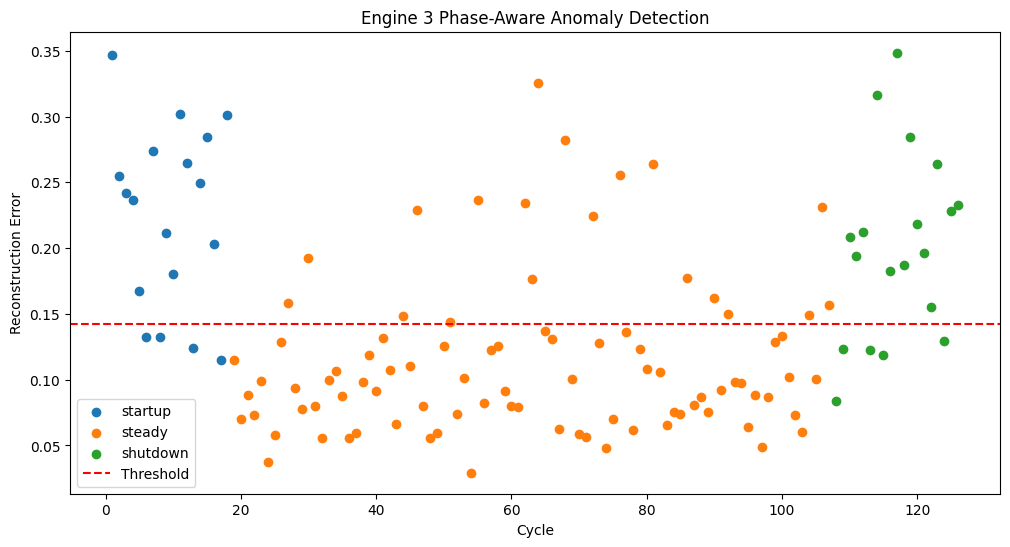

In [24]:
import matplotlib.pyplot as plt

engine_id = 3
subset = test_df[test_df['engine_id']==engine_id]

plt.figure(figsize=(12,6))
for phase in ['startup','steady','shutdown']:
    phase_data = subset[subset['phase']==phase]
    plt.scatter(phase_data['cycle'], phase_data['recon_error'], label=phase)

plt.axhline(y=subset['recon_error'].mean(), color='r', linestyle='--', label="Threshold")
plt.xlabel("Cycle")
plt.ylabel("Reconstruction Error")
plt.title(f"Engine {engine_id} Phase-Aware Anomaly Detection")
plt.legend()
plt.show()


In [25]:
import numpy as np

correlation = np.corrcoef(test_df['RUL'], test_df['recon_error'])[0,1]
print("Correlation between RUL and reconstruction error:", correlation)


Correlation between RUL and reconstruction error: 0.062220332043201244


In [26]:
import joblib

for phase in phase_scalers:
    joblib.dump(phase_scalers[phase], f"{phase}_scaler.pkl")

for phase in phase_models:
    phase_models[phase].save(f"{phase}_autoencoder.h5")

print("✅ Models and scalers saved for deployment")


✅ Models and scalers saved for deployment


In [27]:
import time

def simulate_stream(engine_id=1, delay=0.2):
    subset = test_df[test_df['engine_id']==engine_id]
    for _, row in subset.iterrows():
        print(f"Cycle {row['cycle']} | Phase: {row['phase']} | Anomaly: {row['anomaly']}")
        time.sleep(delay)

simulate_stream(engine_id=1, delay=0.1)


Cycle 1 | Phase: startup | Anomaly: False
Cycle 2 | Phase: startup | Anomaly: False
Cycle 3 | Phase: startup | Anomaly: False
Cycle 4 | Phase: startup | Anomaly: False
Cycle 5 | Phase: steady | Anomaly: False
Cycle 6 | Phase: steady | Anomaly: False
Cycle 7 | Phase: steady | Anomaly: False
Cycle 8 | Phase: steady | Anomaly: False
Cycle 9 | Phase: steady | Anomaly: False
Cycle 10 | Phase: steady | Anomaly: False
Cycle 11 | Phase: steady | Anomaly: False
Cycle 12 | Phase: steady | Anomaly: False
Cycle 13 | Phase: steady | Anomaly: False
Cycle 14 | Phase: steady | Anomaly: False
Cycle 15 | Phase: steady | Anomaly: False
Cycle 16 | Phase: steady | Anomaly: False
Cycle 17 | Phase: steady | Anomaly: False
Cycle 18 | Phase: steady | Anomaly: False
Cycle 19 | Phase: steady | Anomaly: False
Cycle 20 | Phase: steady | Anomaly: False
Cycle 21 | Phase: steady | Anomaly: False
Cycle 22 | Phase: steady | Anomaly: False
Cycle 23 | Phase: steady | Anomaly: False
Cycle 24 | Phase: steady | Anomaly: Fal